# Modélisation — Optimisation du ROI Marketing
### Comparaison multi-modèles + Calcul de l'Impact Marginal
---

## 0. Imports

In [76]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import json
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Modèles ML
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV

# Deep Learning
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Évaluation
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import cross_val_score
from sklearn.inspection import permutation_importance

# Reproductibilité
np.random.seed(42)
tf.random.set_seed(42)

sns.set_theme(style='whitegrid')
print('Imports OK ✅')
print(f'TensorFlow version : {tf.__version__}')

root_dir = Path.cwd().parent

print(tf.config.list_physical_devices('GPU'))

Imports OK ✅
TensorFlow version : 2.16.2
[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 1. Chargement des données préprocessées

In [77]:
X_train = np.load(root_dir / 'pipeline' / 'X_train.npy')
X_test  = np.load(root_dir / 'pipeline' / 'X_test.npy')
y_train = np.load(root_dir / 'pipeline' / 'y_train.npy')
y_test  = np.load(root_dir / 'pipeline' / 'y_test.npy')

with open(root_dir / 'pipeline' / 'feature_names.json') as f:
    feature_names = json.load(f)

print(f'X_train : {X_train.shape} | y_train : {y_train.shape}')
print(f'X_test  : {X_test.shape}  | y_test  : {y_test.shape}')
print(f'Features : {feature_names}')

X_train : (3657, 7) | y_train : (3657,)
X_test  : (915, 7)  | y_test  : (915,)
Features : ['TV', 'Radio', 'Social Media', 'Macro', 'Mega', 'Micro', 'Nano']


## 2. Fonction d'évaluation commune

In [78]:
def evaluate_model(model, X_train, X_test, y_train, y_test, model_name, is_keras=False):
    """
    Calcule MAE, RMSE, R² sur train et test.
    Retourne un dict de résultats.
    """
    if is_keras:
        y_pred_train = model.predict(X_train, verbose=0).flatten()
        y_pred_test  = model.predict(X_test, verbose=0).flatten()
    else:
        y_pred_train = model.predict(X_train)
        y_pred_test  = model.predict(X_test)

    results = {
        'Modèle'       : model_name,
        'MAE Train'    : round(mean_absolute_error(y_train, y_pred_train), 4),
        'MAE Test'     : round(mean_absolute_error(y_test, y_pred_test), 4),
        'RMSE Train'   : round(np.sqrt(mean_squared_error(y_train, y_pred_train)), 4),
        'RMSE Test'    : round(np.sqrt(mean_squared_error(y_test, y_pred_test)), 4),
        'R² Train'     : round(r2_score(y_train, y_pred_train), 4),
        'R² Test'      : round(r2_score(y_test, y_pred_test), 4),
        'y_pred_test'  : y_pred_test
    }

    print(f'\n=== {model_name} ===')
    print(f'  MAE  → Train: {results["MAE Train"]:8.4f} | Test: {results["MAE Test"]:8.4f}')
    print(f'  RMSE → Train: {results["RMSE Train"]:8.4f} | Test: {results["RMSE Test"]:8.4f}')
    print(f'  R²   → Train: {results["R² Train"]:8.4f} | Test: {results["R² Test"]:8.4f}')

    # Détection overfitting
    gap = results['R² Train'] - results['R² Test']
    if gap > 0.05:
        print(f'  ⚠️  Possible overfitting détecté (gap R² = {gap:.4f})')
    else:
        print(f'  ✅ Pas d\'overfitting significatif (gap R² = {gap:.4f})')

    return results

all_results = []
print('Fonction d\'évaluation définie ✅')

Fonction d'évaluation définie ✅


## 3. Modèle 1 — Régression Linéaire (Baseline)

**Justification** : Premier modèle de référence. Avec r=0.9995 entre TV et Sales,
une relation linéaire forte existe. Ses coefficients donnent directement
l'impact marginal de chaque canal — parfait pour notre problématique.
Très interprétable et rapide à entraîner.

In [79]:
lr = LinearRegression()
lr.fit(X_train, y_train)

results_lr = evaluate_model(lr, X_train, X_test, y_train, y_test, 'Régression Linéaire')

# Cross-validation pour robustesse
cv_scores = cross_val_score(lr, X_train, y_train, cv=5, scoring='r2')
print(f'  CV R² (5-fold) : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')
results_lr['CV R²'] = round(cv_scores.mean(), 4)

# Coefficients = impact marginal direct
print('\n  Coefficients (impact marginal direct) :')
for name, coef in zip(feature_names, lr.coef_):
    print(f'    {name:15s} : {coef:+.4f} M€ de ventes par M€ investi')

joblib.dump(lr, root_dir/ 'models' / 'model_linear_regression.pkl')
print('\nModèle sauvegardé ✅')


=== Régression Linéaire ===
  MAE  → Train:   2.8244 | Test:   2.8645
  RMSE → Train:   7.4657 | Test:   8.1130
  R²   → Train:   0.9936 | Test:   0.9921
  ✅ Pas d'overfitting significatif (gap R² = 0.0015)
  CV R² (5-fold) : 0.9937 ± 0.0031

  Coefficients (impact marginal direct) :
    TV              : +91.9985 M€ de ventes par M€ investi
    Radio           : +1.2698 M€ de ventes par M€ investi
    Social Media    : +0.1541 M€ de ventes par M€ investi
    Macro           : -0.4762 M€ de ventes par M€ investi
    Mega            : +0.3854 M€ de ventes par M€ investi
    Micro           : +0.1420 M€ de ventes par M€ investi
    Nano            : -0.0511 M€ de ventes par M€ investi

Modèle sauvegardé ✅


# Modèle 2 — Ridge Regression
**Justification** : même base que la régression linéaire mais avec régularisation L2.
Pénalise les coefficients trop élevés, utile si TV domine trop fortement
et écrase les autres canaux. On compare à la linéaire pour voir
si la régularisation apporte quelque chose sur ce dataset.

In [80]:




# Recherche du meilleur alpha (force de régularisation)
param_grid = {'alpha': [0.01, 0.1, 1, 10, 100, 1000]}
ridge_cv = GridSearchCV(Ridge(), param_grid, cv=5, scoring='r2')
ridge_cv.fit(X_train, y_train)

print(f'Meilleur alpha : {ridge_cv.best_params_["alpha"]}')
print(f'Meilleur CV R² : {ridge_cv.best_score_:.4f}')

ridge = ridge_cv.best_estimator_
results_ridge = evaluate_model(ridge, X_train, X_test, y_train, y_test, 'Ridge')

cv_scores = cross_val_score(ridge, X_train, y_train, cv=5, scoring='r2')
print(f'  CV R² (5-fold) : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')
results_ridge['CV R²'] = round(cv_scores.mean(), 4)

# Coefficients Ridge vs Linéaire
print('\n  Coefficients Ridge :')
for name, coef in zip(feature_names, ridge.coef_):
    print(f'    {name:15s} : {coef:+.4f}')

joblib.dump(ridge, root_dir/ 'models' / 'model_ridge.pkl')
print('\nModèle sauvegardé ✅')

Meilleur alpha : 0.01
Meilleur CV R² : 0.9937

=== Ridge ===
  MAE  → Train:   2.8245 | Test:   2.8646
  RMSE → Train:   7.4657 | Test:   8.1130
  R²   → Train:   0.9936 | Test:   0.9921
  ✅ Pas d'overfitting significatif (gap R² = 0.0015)
  CV R² (5-fold) : 0.9937 ± 0.0031

  Coefficients Ridge :
    TV              : +91.9975
    Radio           : +1.2707
    Social Media    : +0.1541
    Macro           : -0.4762
    Mega            : +0.3853
    Micro           : +0.1420
    Nano            : -0.0511

Modèle sauvegardé ✅


## 4. Modèle 2 — Random Forest

**Justification** : Capture les interactions non-linéaires entre canaux
(ex. effet combiné TV + influenceur Mega). Robuste aux outliers.
Fournit une feature importance native. On compare au baseline
pour voir si la complexité est justifiée.

In [81]:
rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=None,
    min_samples_split=5,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)

results_rf = evaluate_model(rf, X_train, X_test, y_train, y_test, 'Random Forest')

cv_scores = cross_val_score(rf, X_train, y_train, cv=5, scoring='r2')
print(f'  CV R² (5-fold) : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')
results_rf['CV R²'] = round(cv_scores.mean(), 4)

joblib.dump(rf, root_dir/ 'models' / 'model_random_forest.pkl')
print('Modèle sauvegardé ✅')


=== Random Forest ===
  MAE  → Train:   1.5950 | Test:   2.9353
  RMSE → Train:   4.0089 | Test:   6.7512
  R²   → Train:   0.9982 | Test:   0.9945
  ✅ Pas d'overfitting significatif (gap R² = 0.0037)
  CV R² (5-fold) : 0.9937 ± 0.0024
Modèle sauvegardé ✅


## 5. Modèle 3 — XGBoost

**Justification** : Algorithme de boosting qui corrige progressivement
les erreurs des modèles précédents. Généralement très performant
sur des données tabulaires. On l'inclut pour voir s'il surpasse
le Random Forest et si la complexité supplémentaire est justifiée.

In [82]:
xgb = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    verbosity=0
)
xgb.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=False
)

results_xgb = evaluate_model(xgb, X_train, X_test, y_train, y_test, 'XGBoost')

cv_scores = cross_val_score(xgb, X_train, y_train, cv=5, scoring='r2')
print(f'  CV R² (5-fold) : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')
results_xgb['CV R²'] = round(cv_scores.mean(), 4)

joblib.dump(xgb, root_dir/ 'models' / 'model_xgboost.pkl')
print('Modèle sauvegardé ✅')


=== XGBoost ===
  MAE  → Train:   2.0948 | Test:   3.4705
  RMSE → Train:   3.0419 | Test:   7.1241
  R²   → Train:   0.9989 | Test:   0.9939
  ✅ Pas d'overfitting significatif (gap R² = 0.0050)
  CV R² (5-fold) : 0.9933 ± 0.0013
Modèle sauvegardé ✅


## 6. Modèle 4 — MLP (Deep Learning)

**Justification** : Obligatoire selon le sujet. Avec 4572 lignes et
des interactions potentiellement complexes entre canaux et types
d'influenceur, un réseau de neurones peut capturer des patterns
subtils. On analysera si sa complexité est vraiment justifiée
ou si un modèle plus simple suffit (compromis biais/variance).

In [83]:
from sklearn.neural_network import MLPRegressor

mlp = MLPRegressor(
    hidden_layer_sizes=(64, 32, 16),  # même architecture
    activation='relu',
    solver='adam',
    learning_rate_init=0.001,
    max_iter=500,
    early_stopping=True,       # équivalent de notre EarlyStopping
    validation_fraction=0.15,
    n_iter_no_change=15,       # équivalent de patience=15
    random_state=42,
    verbose=True
)

mlp.fit(X_train, y_train)
print('MLP entraîné ✅')

Iteration 1, loss = 23117.97577013
Validation score: -3.818981
Iteration 2, loss = 22978.75201719
Validation score: -3.783238
Iteration 3, loss = 22728.00172116
Validation score: -3.701450
Iteration 4, loss = 22173.43204143
Validation score: -3.521040
Iteration 5, loss = 20923.84026382
Validation score: -3.132054
Iteration 6, loss = 18450.29973929
Validation score: -2.419749
Iteration 7, loss = 14264.79312284
Validation score: -1.345082
Iteration 8, loss = 8674.16276574
Validation score: -0.136609
Iteration 9, loss = 3531.67521709
Validation score: 0.635503
Iteration 10, loss = 1297.98695061
Validation score: 0.778981
Iteration 11, loss = 941.52274563
Validation score: 0.836635
Iteration 12, loss = 714.53562033
Validation score: 0.871324
Iteration 13, loss = 584.08298044
Validation score: 0.893296
Iteration 14, loss = 484.10178961
Validation score: 0.908976
Iteration 15, loss = 413.11408868
Validation score: 0.921237
Iteration 16, loss = 357.61707538
Validation score: 0.930993
Iteratio

In [84]:
# CV R² pour le MLP — modèle séparé sans early_stopping
mlp_cv = MLPRegressor(
    hidden_layer_sizes=(64, 32, 16),
    activation='relu',
    solver='adam',
    learning_rate_init=0.001,
    max_iter=500,
    early_stopping=False,
    random_state=42
)

cv_scores = cross_val_score(mlp_cv, X_train, y_train, cv=5, scoring='r2')
print(f'  CV R² (5-fold) : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')
results_mlp['CV R²'] = round(cv_scores.mean(), 4)

  CV R² (5-fold) : 0.9936 ± 0.0026


In [85]:
results_mlp = evaluate_model(
    mlp, X_train, X_test, y_train, y_test, 'MLP'
)


=== MLP ===
  MAE  → Train:   3.5545 | Test:   3.4848
  RMSE → Train:   7.8177 | Test:   8.2707
  R²   → Train:   0.9930 | Test:   0.9918
  ✅ Pas d'overfitting significatif (gap R² = 0.0012)


In [86]:
joblib.dump(mlp, root_dir/ 'models' / 'model_mlp.pkl')  # plus de .keras

['/Users/joules/Documents/M1/Projet_DT_SC/models/model_mlp.pkl']

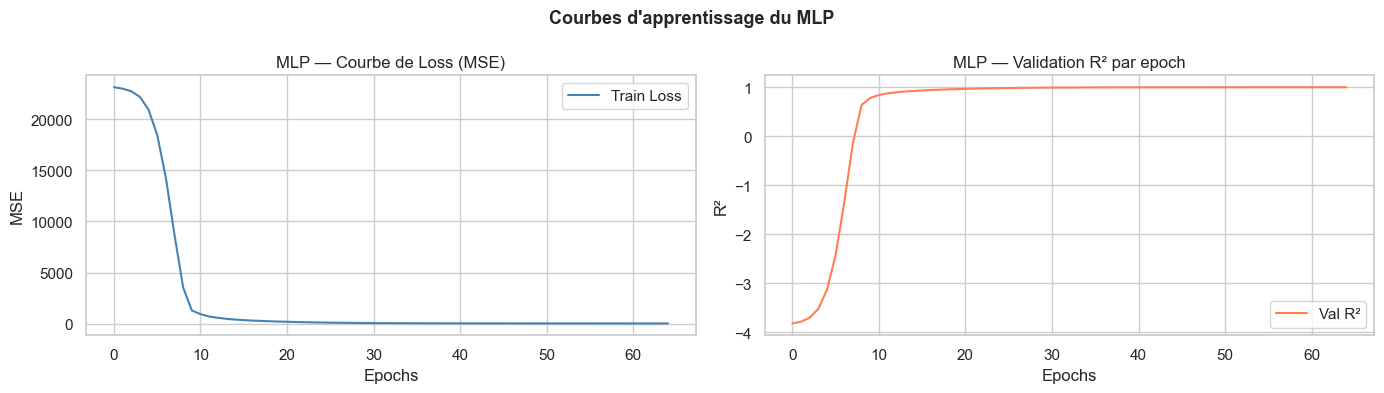

Entraînement arrêté à l'epoch : 65
Meilleure loss obtenue : 33.3810


In [87]:
# Courbe d'apprentissage — sklearn MLPRegressor
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# sklearn stocke uniquement la loss dans loss_curve_
axes[0].plot(mlp.loss_curve_, label='Train Loss', color='steelblue')
if mlp.best_loss_ is not None:
    axes[0].axhline(y=mlp.best_loss_, color='coral', linestyle='--', label=f'Best Loss: {mlp.best_loss_:.2f}')
axes[0].set_title('MLP — Courbe de Loss (MSE)')
axes[0].set_xlabel('Epochs')
axes[0].set_ylabel('MSE')
axes[0].legend()

# Validation loss
if hasattr(mlp, 'validation_scores_') and mlp.validation_scores_ is not None:
    axes[1].plot(mlp.validation_scores_, label='Val R²', color='coral')
    axes[1].set_title('MLP — Validation R² par epoch')
    axes[1].set_xlabel('Epochs')
    axes[1].set_ylabel('R²')
    axes[1].legend()
else:
    axes[1].text(0.5, 0.5, 'Validation score\nnon disponible',
                 ha='center', va='center', transform=axes[1].transAxes)
    axes[1].set_title('MLP — Validation Score')

plt.suptitle('Courbes d\'apprentissage du MLP', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(root_dir/ 'models_output' / 'mlp_learning_curves.png', bbox_inches='tight')
plt.show()

print(f'Entraînement arrêté à l\'epoch : {len(mlp.loss_curve_)}')
if mlp.best_loss_ is not None:
    print(f'Meilleure loss obtenue : {mlp.best_loss_:.4f}')
else:
    print(f'Meilleure loss obtenue : {min(mlp.loss_curve_):.4f}')

## 7. Tableau comparatif des performances

In [88]:
# Compilation des résultats
cols_display = ['Modèle', 'MAE Train', 'MAE Test', 'RMSE Train', 'RMSE Test', 'R² Train', 'R² Test', 'CV R²']
comparison_df = pd.DataFrame([
    {k: v for k, v in r.items() if k in cols_display}
    for r in [results_lr, results_ridge, results_rf, results_xgb, results_mlp]
])

print('=== TABLEAU COMPARATIF DES MODÈLES ===')
print(comparison_df.to_string(index=False))

# Sauvegarde
comparison_df.to_csv(root_dir/ 'models_output' / 'model_comparison.csv', index=False)
print('\nTableau sauvegardé → model_comparison.csv ✅')

=== TABLEAU COMPARATIF DES MODÈLES ===
             Modèle  MAE Train  MAE Test  RMSE Train  RMSE Test  R² Train  R² Test  CV R²
Régression Linéaire     2.8244    2.8645      7.4657     8.1130    0.9936   0.9921 0.9937
              Ridge     2.8245    2.8646      7.4657     8.1130    0.9936   0.9921 0.9937
      Random Forest     1.5950    2.9353      4.0089     6.7512    0.9982   0.9945 0.9937
            XGBoost     2.0948    3.4705      3.0419     7.1241    0.9989   0.9939 0.9933
                MLP     3.5545    3.4848      7.8177     8.2707    0.9930   0.9918    NaN

Tableau sauvegardé → model_comparison.csv ✅


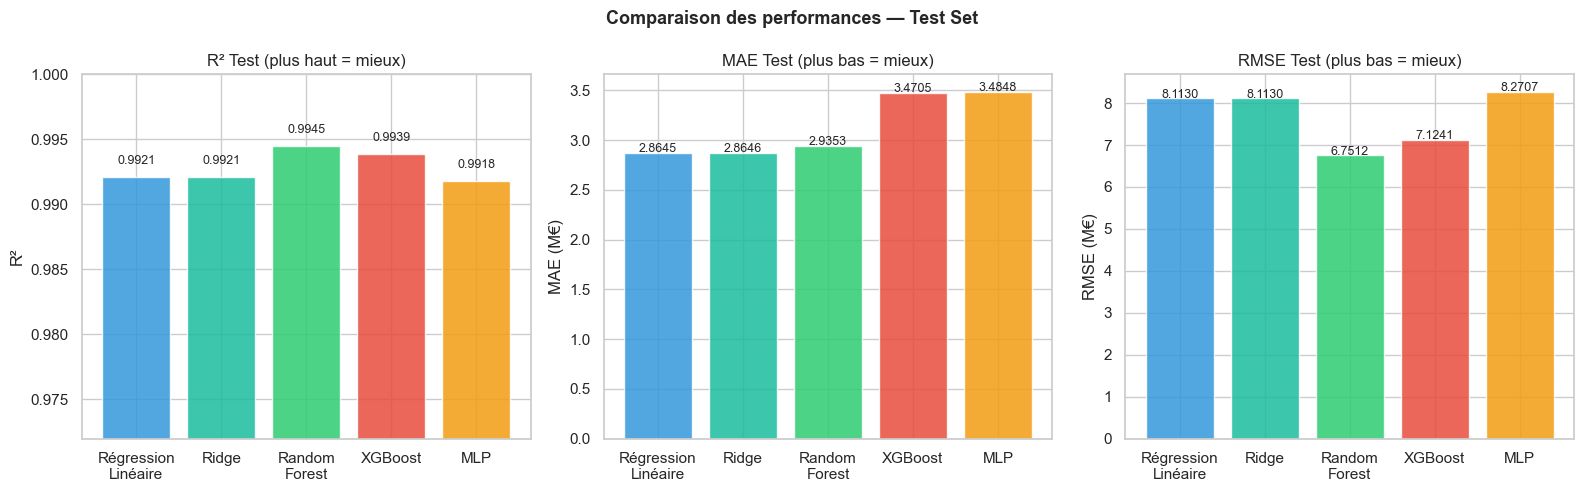

In [89]:
# Visualisation comparative
models = ['Régression\nLinéaire', 'Ridge', 'Random\nForest', 'XGBoost', 'MLP']
r2_test  = [results_lr['R² Test'], results_ridge['R² Test'], results_rf['R² Test'], results_xgb['R² Test'], results_mlp['R² Test']]
mae_test = [results_lr['MAE Test'], results_ridge['MAE Test'], results_rf['MAE Test'], results_xgb['MAE Test'], results_mlp['MAE Test']]
rmse_test= [results_lr['RMSE Test'], results_ridge['RMSE Test'], results_rf['RMSE Test'], results_xgb['RMSE Test'], results_mlp['RMSE Test']]

colors = ['#3498db', '#1abc9c', '#2ecc71', '#e74c3c', '#f39c12']

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].bar(models, r2_test, color=colors, edgecolor='white', alpha=0.85)
axes[0].set_title('R² Test (plus haut = mieux)')
axes[0].set_ylabel('R²')
axes[0].set_ylim([min(r2_test)*0.98, 1.0])
for i, v in enumerate(r2_test):
    axes[0].text(i, v + 0.001, f'{v:.4f}', ha='center', fontsize=9)

axes[1].bar(models, mae_test, color=colors, edgecolor='white', alpha=0.85)
axes[1].set_title('MAE Test (plus bas = mieux)')
axes[1].set_ylabel('MAE (M€)')
for i, v in enumerate(mae_test):
    axes[1].text(i, v + 0.01, f'{v:.4f}', ha='center', fontsize=9)

axes[2].bar(models, rmse_test, color=colors, edgecolor='white', alpha=0.85)
axes[2].set_title('RMSE Test (plus bas = mieux)')
axes[2].set_ylabel('RMSE (M€)')
for i, v in enumerate(rmse_test):
    axes[2].text(i, v + 0.01, f'{v:.4f}', ha='center', fontsize=9)

plt.suptitle('Comparaison des performances — Test Set', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(root_dir/ 'models_output' / 'model_comparison.png', bbox_inches='tight')
plt.show()

## 8. Analyse des résidus

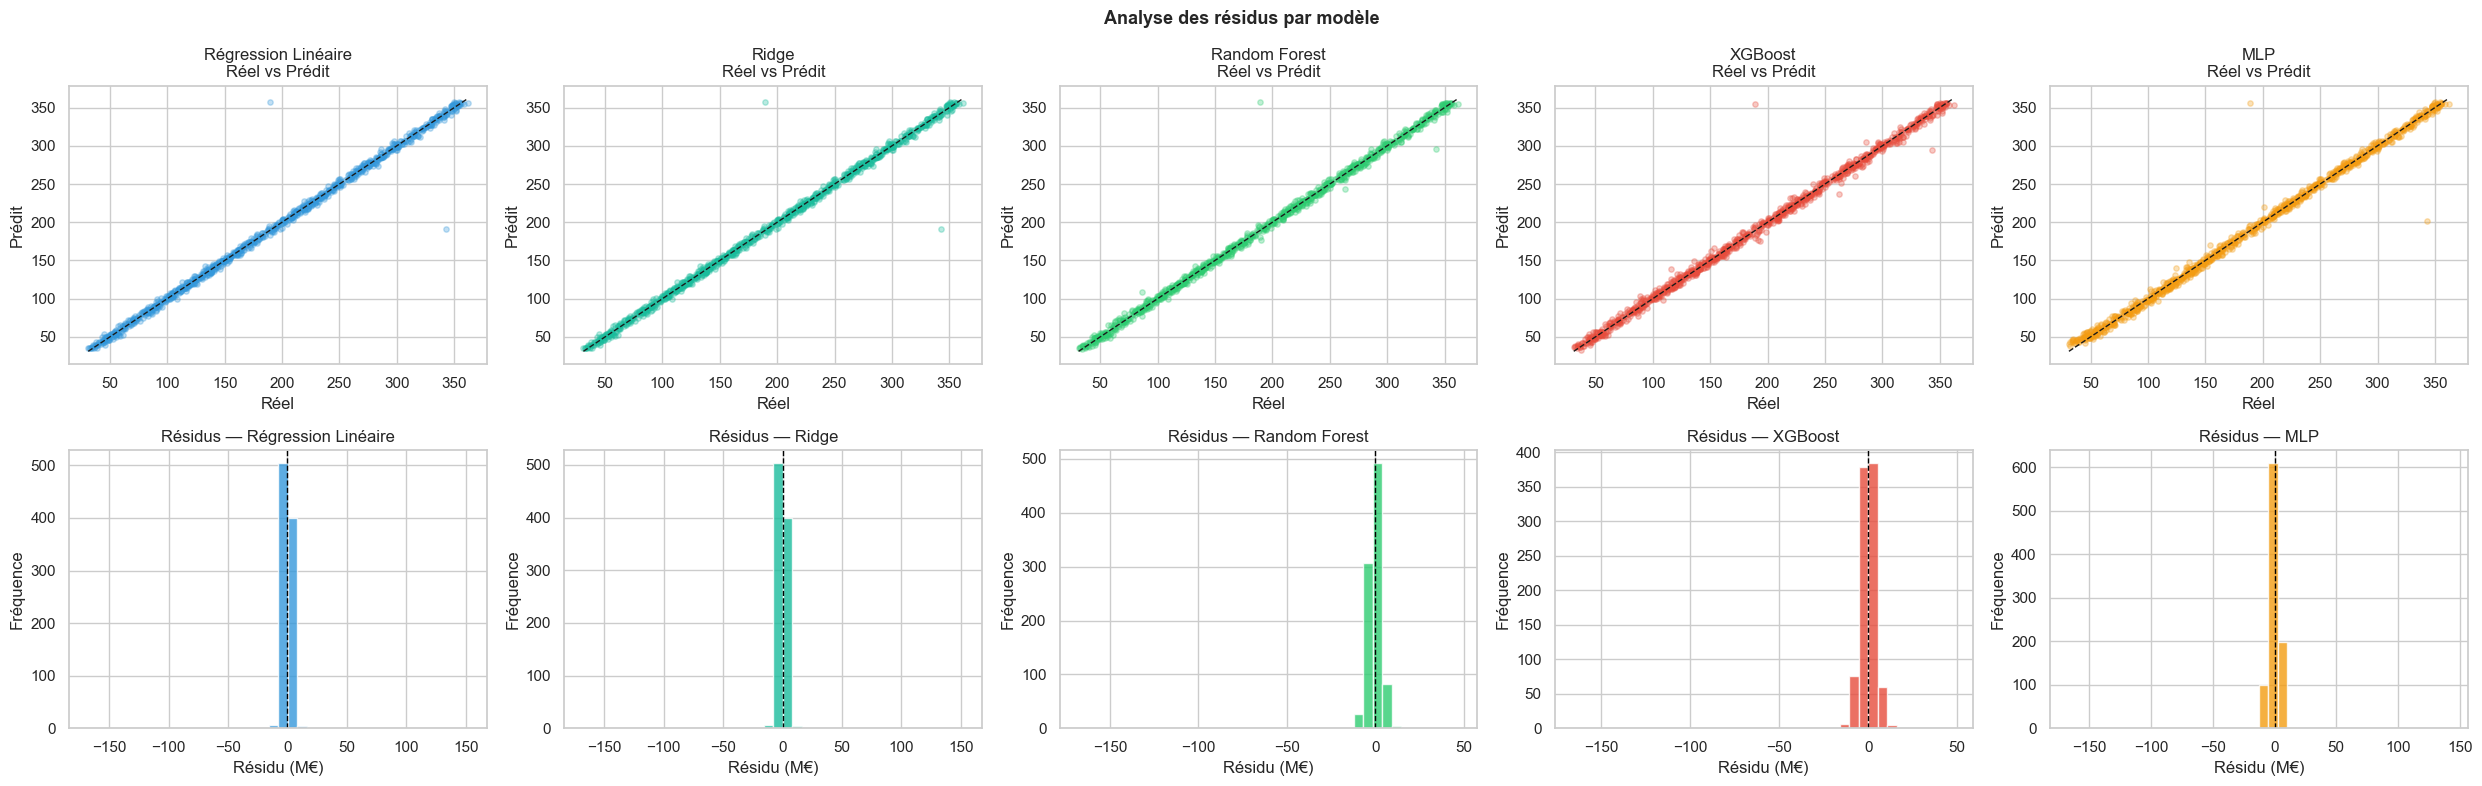

In [90]:
fig, axes = plt.subplots(2, 5, figsize=(25, 8))

model_results = [
    ('Régression Linéaire', results_lr['y_pred_test']),
    ('Ridge',               results_ridge['y_pred_test']),
    ('Random Forest',       results_rf['y_pred_test']),
    ('XGBoost',             results_xgb['y_pred_test']),
    ('MLP',                 results_mlp['y_pred_test']),
]

for i, (name, y_pred) in enumerate(model_results):
    residuals = y_test - y_pred

    # Scatter : valeurs réelles vs prédites
    axes[0, i].scatter(y_test, y_pred, alpha=0.3, s=15, color=colors[i])
    min_val = min(y_test.min(), y_pred.min())
    max_val = max(y_test.max(), y_pred.max())
    axes[0, i].plot([min_val, max_val], [min_val, max_val], 'k--', linewidth=1)
    axes[0, i].set_title(f'{name}\nRéel vs Prédit')
    axes[0, i].set_xlabel('Réel')
    axes[0, i].set_ylabel('Prédit')

    # Distribution des résidus
    axes[1, i].hist(residuals, bins=40, color=colors[i], edgecolor='white', alpha=0.8)
    axes[1, i].axvline(x=0, color='black', linestyle='--', linewidth=1)
    axes[1, i].set_title(f'Résidus — {name}')
    axes[1, i].set_xlabel('Résidu (M€)')
    axes[1, i].set_ylabel('Fréquence')

plt.suptitle('Analyse des résidus par modèle', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(root_dir/ 'models_output' / 'residuals_analysis.png', bbox_inches='tight')
plt.show()

## 9. Feature Importance

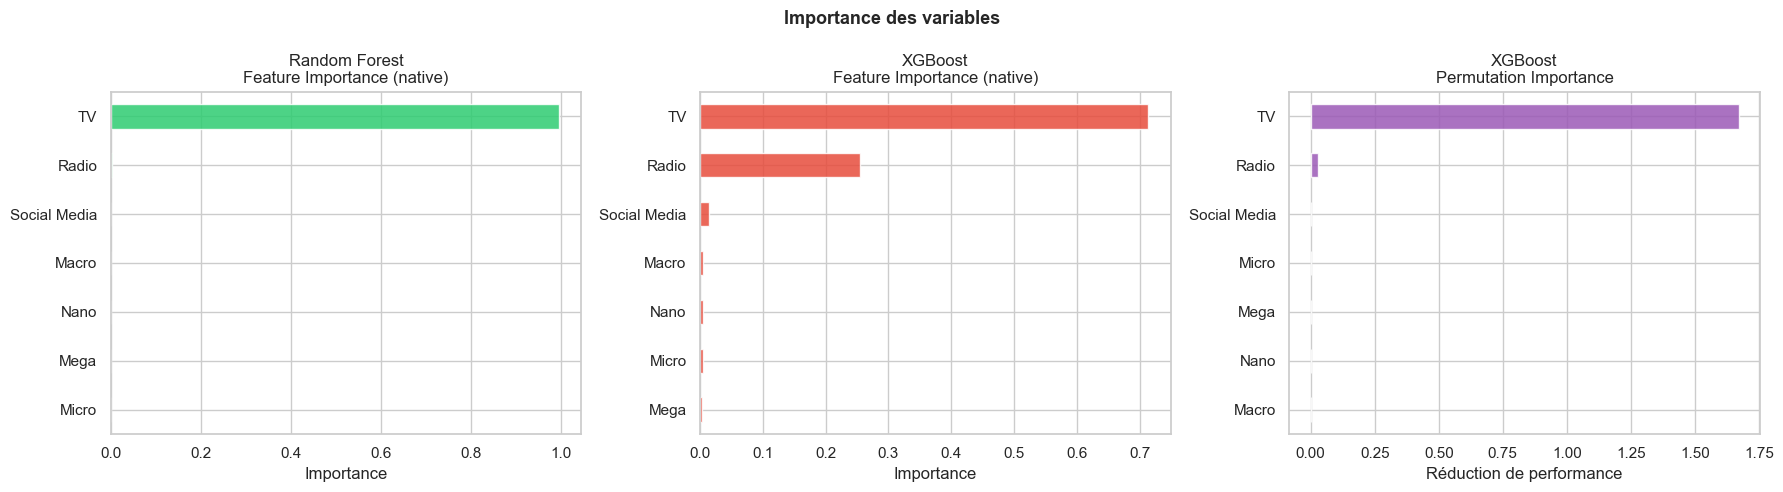

In [91]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Random Forest — importance native
rf_imp = pd.Series(rf.feature_importances_, index=feature_names).sort_values(ascending=True)
rf_imp.plot(kind='barh', ax=axes[0], color='#2ecc71', edgecolor='white', alpha=0.85)
axes[0].set_title('Random Forest\nFeature Importance (native)')
axes[0].set_xlabel('Importance')

# XGBoost — importance native
xgb_imp = pd.Series(xgb.feature_importances_, index=feature_names).sort_values(ascending=True)
xgb_imp.plot(kind='barh', ax=axes[1], color='#e74c3c', edgecolor='white', alpha=0.85)
axes[1].set_title('XGBoost\nFeature Importance (native)')
axes[1].set_xlabel('Importance')

# Permutation Importance sur le meilleur modèle sklearn
# (on prend XGBoost comme exemple)
perm_imp = permutation_importance(xgb, X_test, y_test, n_repeats=10, random_state=42)
perm_series = pd.Series(perm_imp.importances_mean, index=feature_names).sort_values(ascending=True)
perm_series.plot(kind='barh', ax=axes[2], color='#9b59b6', edgecolor='white', alpha=0.85)
axes[2].set_title('XGBoost\nPermutation Importance')
axes[2].set_xlabel('Réduction de performance')

plt.suptitle('Importance des variables', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(root_dir/ 'models_output' / 'feature_importance.png', bbox_inches='tight')
plt.show()

## 10. Calcul de l'Impact Marginal — Notre Problématique

### Méthode : simulation
Pour chaque canal, on augmente le budget de +1 M€ (toutes choses égales par ailleurs)
et on mesure la différence de prédiction de ventes.
C'est la définition de la dérivée partielle numérique.

In [92]:
def compute_marginal_impact(model, X_test, feature_names, delta=1.0, is_keras=False):
    """
    Calcule l'impact marginal de chaque canal numérique.
    On augmente le budget de +delta (en unités standardisées)
    et on mesure la variation moyenne de prédiction.
    """
    # Indices des canaux numériques (TV=0, Radio=1, Social Media=2)
    numeric_indices = [0, 1, 2]
    numeric_names   = ['TV', 'Radio', 'Social Media']

    if is_keras:
        baseline = model.predict(X_test, verbose=0).flatten()
    else:
        baseline = model.predict(X_test)

    impacts = {}
    for idx, name in zip(numeric_indices, numeric_names):
        X_perturbed = X_test.copy()
        X_perturbed[:, idx] += delta  # +1 unité standardisée

        if is_keras:
            perturbed_pred = model.predict(X_perturbed, verbose=0).flatten()
        else:
            perturbed_pred = model.predict(X_perturbed)

        impact = (perturbed_pred - baseline).mean()
        impacts[name] = round(impact, 4)

    return impacts

print('Fonction d\'impact marginal définie ✅')

Fonction d'impact marginal définie ✅


In [93]:
print('=== IMPACT MARGINAL PAR CANAL ET PAR MODÈLE ===')
print('(Augmentation moyenne des ventes pour +1 unité standardisée de budget)\n')

impact_lr  = compute_marginal_impact(lr,  X_test, feature_names)
impact_ridge = compute_marginal_impact(ridge, X_test, feature_names)
impact_rf  = compute_marginal_impact(rf,  X_test, feature_names)
impact_xgb = compute_marginal_impact(xgb, X_test, feature_names)
impact_mlp = compute_marginal_impact(mlp, X_test, feature_names)

impact_df = pd.DataFrame([
    {'Modèle': 'Régression Linéaire', **impact_lr},
    {'Modèle': 'Ridge',               **impact_ridge},
    {'Modèle': 'Random Forest',       **impact_rf},
    {'Modèle': 'XGBoost',             **impact_xgb},
    {'Modèle': 'MLP',                 **impact_mlp},
])

print(impact_df.to_string(index=False))
impact_df.to_csv(root_dir/ 'models_output' / 'marginal_impact.csv', index=False)
print('\nRésultats sauvegardés → marginal_impact.csv ✅')

=== IMPACT MARGINAL PAR CANAL ET PAR MODÈLE ===
(Augmentation moyenne des ventes pour +1 unité standardisée de budget)

             Modèle        TV  Radio  Social Media
Régression Linéaire 91.998500 1.2698        0.1541
              Ridge 91.997500 1.2707        0.1541
      Random Forest 78.381400 2.5021        0.0067
            XGBoost 75.443199 5.7884       -0.0571
                MLP 92.020000 4.6191        1.0550

Résultats sauvegardés → marginal_impact.csv ✅


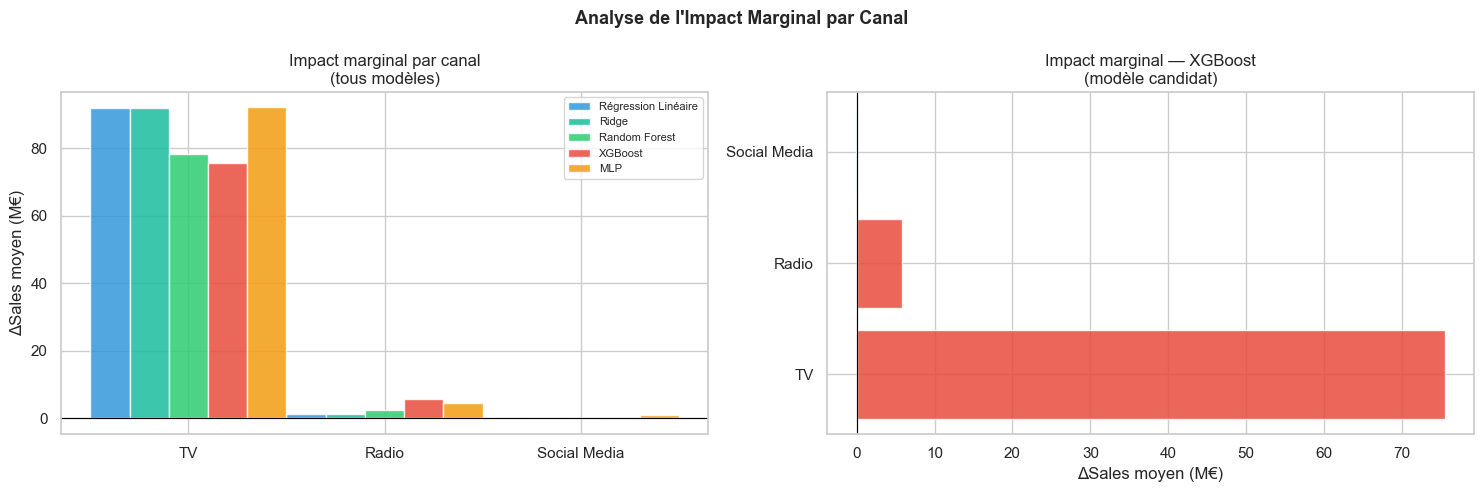

In [94]:
# Visualisation de l'impact marginal
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Par canal pour chaque modèle
canaux = ['TV', 'Radio', 'Social Media']
x = np.arange(len(canaux))
width = 0.2

models_impacts = [
    ('Régression Linéaire', impact_lr,    '#3498db'),
    ('Ridge',               impact_ridge, '#1abc9c'),
    ('Random Forest',       impact_rf,    '#2ecc71'),
    ('XGBoost',             impact_xgb,   '#e74c3c'),
    ('MLP',                 impact_mlp,   '#f39c12'),
]

for i, (name, impact, color) in enumerate(models_impacts):
    vals = [impact[c] for c in canaux]
    axes[0].bar(x + i*width, vals, width, label=name, color=color, alpha=0.85, edgecolor='white')

axes[0].set_xticks(x + width*2)
axes[0].set_xticklabels(canaux)
axes[0].set_title('Impact marginal par canal\n(tous modèles)')
axes[0].set_ylabel('ΔSales moyen (M€)')
axes[0].legend(fontsize=8)
axes[0].axhline(y=0, color='black', linewidth=0.8)

# Impact marginal du meilleur modèle (à adapter selon résultats)
# On prend XGBoost comme exemple
best_impact = impact_xgb
sorted_impact = dict(sorted(best_impact.items(), key=lambda x: abs(x[1]), reverse=True))
axes[1].barh(list(sorted_impact.keys()), list(sorted_impact.values()),
             color=['#e74c3c' if v > 0 else '#3498db' for v in sorted_impact.values()],
             edgecolor='white', alpha=0.85)
axes[1].set_title('Impact marginal — XGBoost\n(modèle candidat)')
axes[1].set_xlabel('ΔSales moyen (M€)')
axes[1].axvline(x=0, color='black', linewidth=0.8)

plt.suptitle('Analyse de l\'Impact Marginal par Canal', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(root_dir/ 'models_output' / 'marginal_impact.png', bbox_inches='tight')
plt.show()

## 11. Sélection et justification du modèle final

In [95]:
print('=' * 55)
print('SYNTHÈSE — SÉLECTION DU MODÈLE FINAL')
print('=' * 55)
print()
print(comparison_df[['Modèle', 'R² Test', 'MAE Test', 'RMSE Test', 'CV R²']].to_string(index=False))
print()
print('Critères de sélection :')
print('  1. Performance  → R² Test le plus élevé, MAE/RMSE les plus bas')
print('  2. Stabilité    → gap Train/Test faible, CV R² cohérent')
print('  3. Interprétabilité → feature importance disponible')
print('  4. Complexité   → coût computationnel justifié')
print()
print('→ Adapter la conclusion selon vos résultats obtenus.')
print('  Exemple : si XGBoost domine sur tous les critères,')
print('  le choisir comme modèle final et justifier pourquoi.')

SYNTHÈSE — SÉLECTION DU MODÈLE FINAL

             Modèle  R² Test  MAE Test  RMSE Test  CV R²
Régression Linéaire   0.9921    2.8645     8.1130 0.9937
              Ridge   0.9921    2.8646     8.1130 0.9937
      Random Forest   0.9945    2.9353     6.7512 0.9937
            XGBoost   0.9939    3.4705     7.1241 0.9933
                MLP   0.9918    3.4848     8.2707    NaN

Critères de sélection :
  1. Performance  → R² Test le plus élevé, MAE/RMSE les plus bas
  2. Stabilité    → gap Train/Test faible, CV R² cohérent
  3. Interprétabilité → feature importance disponible
  4. Complexité   → coût computationnel justifié

→ Adapter la conclusion selon vos résultats obtenus.
  Exemple : si XGBoost domine sur tous les critères,
  le choisir comme modèle final et justifier pourquoi.


In [96]:
# Sauvegarde du modèle final choisi
# ⚠️ Remplace 'xgb' par le modèle que tu sélectionnes
best_model = xgb
best_model_name = 'XGBoost'

joblib.dump(best_model, root_dir/ 'models' / 'best_model.pkl')
print(f'Modèle final ({best_model_name}) sauvegardé → best_model.pkl ✅')
print()
print('Fichiers générés :')
print('  model_linear_regression.pkl')
print('  model_random_forest.pkl')
print('  model_xgboost.pkl')
print('  model_mlp.keras')
print('  best_model.pkl')
print('  model_comparison.csv')
print('  marginal_impact.csv')
print('  mlp_learning_curves.png')
print('  model_comparison.png')
print('  residuals_analysis.png')
print('  feature_importance.png')
print('  marginal_impact.png')
print()
print('🚀 Prêt pour le dashboard et SHAP !')

Modèle final (XGBoost) sauvegardé → best_model.pkl ✅

Fichiers générés :
  model_linear_regression.pkl
  model_random_forest.pkl
  model_xgboost.pkl
  model_mlp.keras
  best_model.pkl
  model_comparison.csv
  marginal_impact.csv
  mlp_learning_curves.png
  model_comparison.png
  residuals_analysis.png
  feature_importance.png
  marginal_impact.png

🚀 Prêt pour le dashboard et SHAP !
